Regressione SVM

In [3]:
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = load_diabetes()
X = data.data
y = data.target

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# calcolo svm con modello lineare

svr_linear = SVR(kernel='linear', C=1.0, epsilon=5.0)
svr_linear.fit(X_scaled, y)
y_pred_lin = svr_linear.predict(X_scaled)
mse_linear = mean_squared_error(y, y_pred_lin)
r2_linear = r2_score(y, y_pred_lin)


In [7]:
# calcolo svm con modello rbf (stesso epsilon)

svr_rbf_narrow = SVR(kernel='rbf', C=1.0, epsilon=5.0)
svr_rbf_narrow.fit(X_scaled, y)
y_pred_narrow = svr_rbf_narrow.predict(X_scaled)
mse_narrow = mean_squared_error(y, y_pred_narrow)
r2_narrow = r2_score(y, y_pred_narrow)

In [8]:
# calcolo svm con modello rbf (epsilon maggiore)

svr_rbf_wide = SVR(kernel='rbf', C=1.0, epsilon=20.0)
svr_rbf_wide.fit(X_scaled, y)
y_pred_wide = svr_rbf_wide.predict(X_scaled)
mse_wide = mean_squared_error(y, y_pred_wide)
r2_wide = r2_score(y, y_pred_wide)

In [10]:
print("LINEAR")
print(f"\tMSE:\t{mse_linear}\n\tR2\t{r2_linear}")
print("RBF (eps = 5)")
print(f"\tMSE:\t{mse_narrow}\n\tR2\t{r2_narrow}")
print("RBF (eps = 20)")
print(f"\tMSE:\t{mse_wide}\n\tR2\t{r2_wide}")

LINEAR
	MSE:	2902.7753622147666
	R2	0.510483691896417
RBF (eps = 5)
	MSE:	4644.061193263366
	R2	0.21683788572640994
RBF (eps = 20)
	MSE:	4662.159243124349
	R2	0.21378587878603694


In [11]:
# plot dei modelli sugli stessi dati rendendo il dataset bidimensionale

import pandas as pd

pd.DataFrame(X, columns=data.feature_names)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [13]:
feature_index = 2 # scelta della colonna bmi

# ordiniamo i punti in ordine crescente altrimenti la retta non ha senso nel grafico (sia le feature [X] che le label [y])

sort_idx = X_scaled[:, feature_index].argsort()
X_plot = X_scaled[sort_idx, feature_index]
y_pred_narrow_plot = y_pred_narrow[sort_idx]
y_pred_wide_plot = y_pred_wide[sort_idx]
y_pred_linear_plot = y_pred_lin[sort_idx]


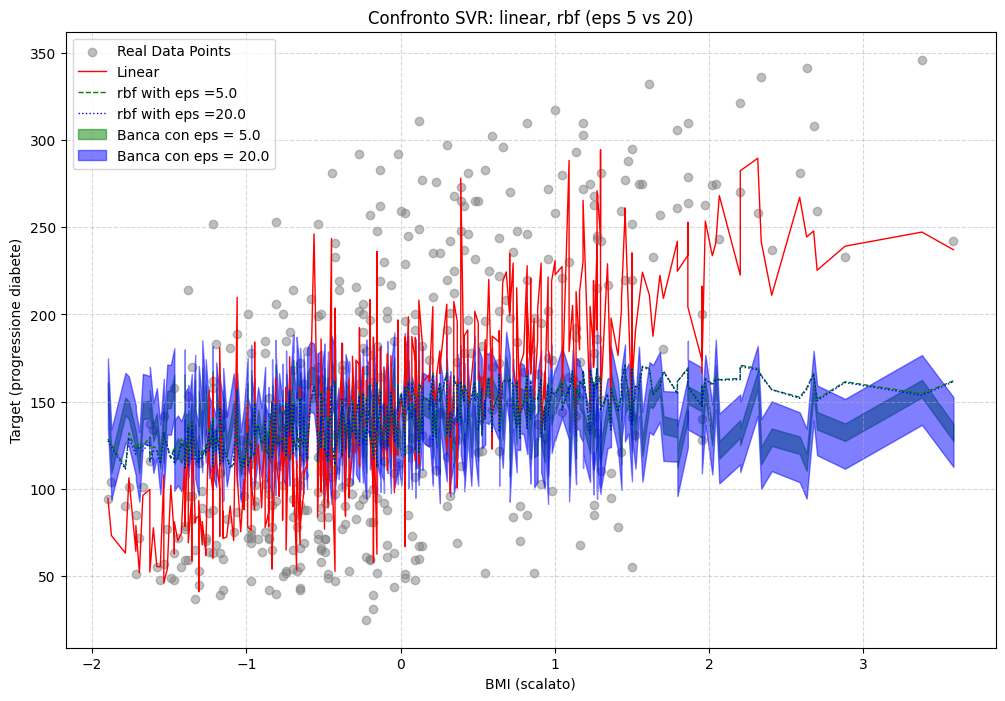

In [15]:
plt.figure(figsize=(12,8))
plt.scatter(X_scaled[:, feature_index], y, color="grey", alpha=0.5, label="Real Data Points")
plt.plot(X_plot, y_pred_linear_plot, color="red", linestyle="-", linewidth=1, label="Linear")
plt.plot(X_plot, y_pred_narrow_plot, color="green", linestyle="--", linewidth=1, label="rbf with eps =5.0")
plt.plot(X_plot, y_pred_wide_plot, color="blue", linestyle=":", linewidth=1, label="rbf with eps =20.0")

# rappresentazione di epsilon

# con epsilon -5 e +5
plt.fill_between(X_plot, y_pred_narrow - 5, y_pred_narrow + 5, color="green", alpha=0.5, label="Banca con eps = 5.0" )
# con epsilon -20 e +20
plt.fill_between(X_plot, y_pred_wide - 20, y_pred_wide + 20, color="blue", alpha=0.5, label="Banca con eps = 20.0" )

plt.title("Confronto SVR: linear, rbf (eps 5 vs 20)")
plt.xlabel("BMI (scalato)")
plt.ylabel("Target (progressione diabete)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
